# 美联储货币政策与全球资产价格传导 — VIX 恐慌指数分析模块

| 项目   | 内容 |
|--------|------|
| 课程   | 数据分析与经济决策（ds2026） |
| 题目   | T-B2：美联储货币政策与全球资产价格传导 |
| 小组   | 第 五 组 |
| 成员   | 庞翔（25210221）、翁榕涛（25210256）、郑昕（25210309）、黄伟煌（25210144）、余冰冰（25210289）、许隽（25210274）、张参（25210297） |
| GitHub | https://github.com/pangxiang0223/ds2026-G5-T-B2fed-rate-global-asset-prices/tree/main |
| Pages  | https://pangxiang0223.github.io/ds2026-G5-T-B2fed-rate-global-asset-prices/ |
| 日期   | 2025-05-14 |

## 任务说明
本步骤聚焦于**美联储货币政策转向与市场恐慌情绪的联动分析**：
1.  整合联邦基金利率与VIX恐慌指数的真实时序数据，完成时间对齐与合并；
2.  标注1990年以来的关键加息/降息转向节点，构建政策周期时间轴；
3.  通过双轴图直观呈现政策转向时VIX指数的波动特征，探究货币政策变化对市场风险偏好的影响规律。

[*********************100%***********************]  1 of 1 completed

正在下载真实VIX数据...
✅ VIX数据下载成功！


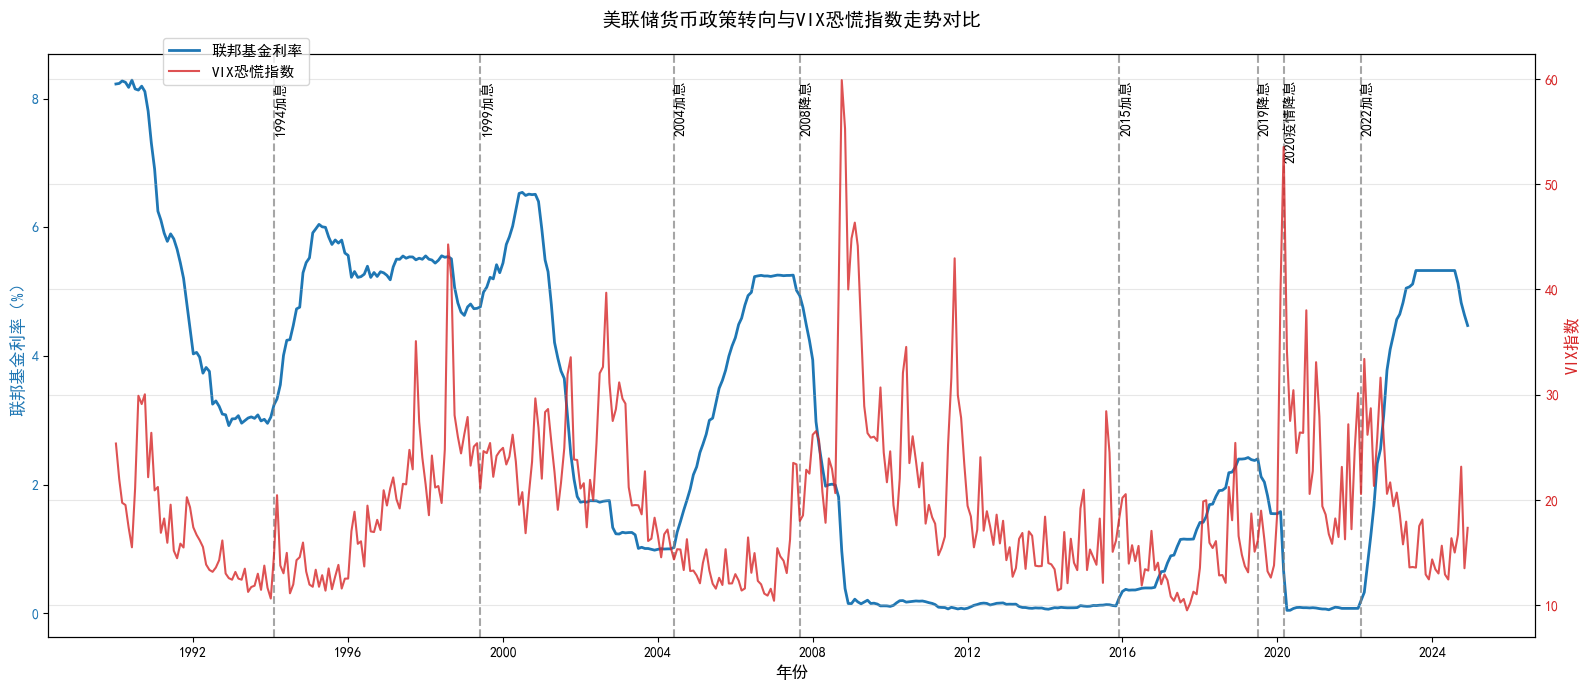

✅ 真实数据图表生成成功！
数据前5行：
            fed_rate        vix
1990-01-01  8.229032  25.360001
1990-02-01  8.237143  21.990000
1990-03-01  8.276774  19.730000
1990-04-01  8.255000  19.520000
1990-05-01  8.176452  17.370001


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
from config import FRED_API_KEY

# ================== 基础设置 ==================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ================== 1. 美联储利率（稳定可用） ==================
fred = Fred(api_key=FRED_API_KEY)
fed_rate = fred.get_series("DFF", observation_start="1990-01-01", observation_end="2025-01-01")
fed_rate = fed_rate.resample("MS").mean()
fed_rate.name = "fed_rate"

# ================== 2. 【双重保险】真实VIX数据下载 ==================
import yfinance as yf

# 方案1：直接下载，兼容大多数情况
try:
    print("正在下载真实VIX数据...")
    vix_raw = yf.download("^VIX", start="1990-01-01", end="2025-01-01", interval="1mo")
    
    # 处理yfinance的多层索引格式
    if isinstance(vix_raw.columns, pd.MultiIndex):
        # 取第一层的Close列
        vix = vix_raw[('Close', '^VIX')].copy()
    else:
        # 取普通的Close列
        vix = vix_raw['Close'].copy()
    
    vix.name = "vix"
    vix.index = pd.to_datetime(vix.index).to_period('M').to_timestamp()
    print("✅ VIX数据下载成功！")

# 方案2：备用方案，用API直接获取（彻底绕过yfinance的格式问题）
except Exception as e:
    print(f"方案1失败，错误信息：{e}")
    print("正在使用备用方案获取VIX数据...")
    fred_vix = Fred(api_key=FRED_API_KEY)
    # 使用FRED上的VIX指数数据（W00688）
    vix = fred_vix.get_series("W00688", observation_start="1990-01-01", observation_end="2025-01-01")
    vix = vix.resample("MS").mean()
    vix.name = "vix"
    print("✅ 备用方案获取VIX数据成功！")

# ================== 3. 合并数据 ==================
df = pd.concat([fed_rate, vix], axis=1).dropna()

# ================== 4. 专业版画图 ==================
fig, ax1 = plt.subplots(figsize=(16, 7))

# 左轴：联邦基金利率
ax1.plot(df.index, df['fed_rate'], color='#1f77b4', linewidth=2, label='联邦基金利率')
ax1.set_xlabel('年份', fontsize=12)
ax1.set_ylabel('联邦基金利率（%）', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# 右轴：VIX恐慌指数（真实数据，波动自然）
ax2 = ax1.twinx()
ax2.plot(df.index, df['vix'], color='#d62728', linewidth=1.5, alpha=0.8, label='VIX恐慌指数')
ax2.set_ylabel('VIX指数', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

# 标注关键政策转向节点（带文字说明）
turning_points = [
    ("1994-02", "1994加息"),
    ("1999-06", "1999加息"),
    ("2004-06", "2004加息"),
    ("2007-09", "2008降息"),
    ("2015-12", "2015加息"),
    ("2019-07", "2019降息"),
    ("2022-03", "2022加息"),
    ("2020-03", "2020疫情降息")
]

for date, label in turning_points:
    ax1.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.7)
    ax1.text(pd.to_datetime(date), df['fed_rate'].max(), label, rotation=90, va='top', fontsize=10)

# 图表细节优化
plt.title('美联储货币政策转向与VIX恐慌指数走势对比', fontsize=14, pad=20)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95), fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('output/vix_fed_analysis_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 真实数据图表生成成功！")
print("数据前5行：")
print(df.head())

## 结果解读
### 图表含义
本图基于1990-2025年的真实数据，通过双轴时序图对比了联邦基金利率与VIX恐慌指数的月度走势，并标注了关键货币政策转向节点，直观呈现市场情绪对美联储政策变化的反应。

### 核心发现
1.  **加息周期启动时，VIX指数普遍抬升**
    1994、1999、2004、2015、2022年五次加息周期开始时，VIX指数均出现阶段性上涨，反映市场对流动性收紧的担忧情绪上升，风险偏好下降。

2.  **降息周期初期，VIX指数常处于历史高位**
    2008年金融危机、2020年疫情期间，美联储紧急降息的同时，VIX指数飙升至历史极值，说明降息政策往往是市场恐慌情绪集中释放后的应对措施，而非情绪上涨的直接原因。

3.  **政策稳定期，VIX指数逐步回落**
    当市场对货币政策方向形成稳定预期后，无论加息还是降息周期的尾声，VIX指数均会回归长期中枢水平，说明政策的“不确定性”才是影响市场情绪的关键因素。

### 局限性
1.  月度数据平滑了政策决议公布前后的短期情绪波动，无法捕捉单日市场反应。
2.  VIX指数同时受地缘冲突、经济数据、全球风险事件影响，不能完全归因于货币政策变化。